# Centrality groups and stock volatility

This notebook tests whether a company's position in the co-mention graph is associated with its financial risk.

Hypothesis:

> More central companies may have different annualised volatility than peripheral companies.

## Methodology

This notebook tests whether a company's position in the co-mention graph is related to its stock risk.

The graph variable is **PageRank centrality**. PageRank measures how important a node is in the graph, taking into account not only how many connections it has, but also how important its neighbours are. In this project, a company has high PageRank if it is frequently co-mentioned with other central companies.

The financial variable is **annualised volatility**, computed from daily log-returns over 2017-2019:

```text
annualised volatility = std(daily log-returns) × sqrt(252)
This measures how strongly a stock fluctuates over time. Higher volatility means higher risk or more unstable price movement.

The statistical design is:

Merge the graph centrality table with the financial table.
Split companies into three equal-sized PageRank groups:
low centrality
middle centrality
high centrality
Compare annualised volatility across these three groups.
Use Shapiro-Wilk tests to check normality and Levene's test to check equality of variances.
Since the volatility distributions are not normal and variances are unequal, use Welch ANOVA as the main omnibus test.
If the omnibus test is significant, compare high-centrality and low-centrality companies directly using Welch's two-sample t-test.
Finally, treat PageRank as a continuous variable and compute Pearson and Spearman correlations with volatility.

The null hypothesis for the group test is:

H0: low, middle, and high PageRank companies have the same mean annualised volatility.
The alternative hypothesis is:

H1: at least one PageRank group has a different mean annualised volatility.


In [14]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

HERE = Path('.').resolve()
RANDOM_STATE = 42
rng = np.random.default_rng(RANDOM_STATE)


## 1. Load precomputed graph centrality and financial data

In [15]:
graph_nodes = pd.read_csv(HERE / 'louvain_clusters_with_industries_degrees_ranks.csv')
fin = pd.read_csv(HERE / 'company_financials.csv')

print(f'precomputed graph nodes: {len(graph_nodes):,}')
print(f'financial rows: {len(fin):,}')

precomputed graph nodes: 1,172
financial rows: 727


## 2. Inspect the precomputed centrality table

`louvain_clusters_with_industries_degrees_ranks.csv` contains Louvain cluster labels and centrality measures.

In [16]:
required = ['company_id', 'company', 'ticker', 'industry_group', 'cluster',
            'degree', 'degree_centrality', 'weighted_degree', 'betweenness', 'pagerank']
missing = [c for c in required if c not in graph_nodes.columns]
if missing:
    raise ValueError(f'Missing required graph columns: {missing}')

graph_nodes[required].sort_values('pagerank', ascending=False).head(10)

,company_id,company,ticker,industry_group,cluster,degree,degree_centrality,weighted_degree,betweenness,pagerank
0,Q312,Apple Inc.,AAPL,Technology / Telecom,0,234,0.199829,1126,0.433388,0.023396
2,Q3884,Amazon,AMZN,Technology / Telecom,0,200,0.170794,979,0.392921,0.020163
1,Q95,Google,GOOGL,Technology / Telecom,0,178,0.152007,910,0.213066,0.018174
4,Q2283,Microsoft,MSFT,Technology / Telecom,0,189,0.161401,800,0.186744,0.016861
6,Q334204,Morgan Stanley,MS,Finance,8,215,0.183604,786,0.300643,0.016688
5,Q193326,Goldman Sachs,GS,Finance,8,193,0.164816,684,0.061768,0.014179
9,Q66048,Deutsche Bank,DB,Finance,8,159,0.135781,559,0.062141,0.011841
7,Q219508,Citigroup,C,Finance,8,142,0.121264,561,0.098203,0.011555
3,Q20800404,Alphabet Inc.,GOOG,Technology / Telecom,0,103,0.087959,589,0.118767,0.011309
10,Q372657,Credit Suisse,CS,Finance,8,137,0.116994,496,0.079974,0.010736


## 3. Merge centrality with financial variables

PageRank is the main centrality measure because it rewards connections to other important companies. Weighted degree and betweenness are kept as robustness measures.

In [17]:
centrality = graph_nodes[required].copy()
centrality['ticker'] = centrality['ticker'].astype(str).str.strip()

df = centrality.merge(
    fin[['company_id', 'ticker', 'vol_annualised', 'cum_return', 'sharpe_proxy', 'sector_coarse', 'article_count']],
    on=['company_id', 'ticker'], how='inner'
).dropna(subset=['vol_annualised', 'pagerank'])
df['sector_final'] = df['sector_coarse'].where(df['sector_coarse'].notna(), df['industry_group'])

df['log_pagerank'] = np.log10(df['pagerank'].clip(lower=1e-12))
df['log_weighted_degree'] = np.log1p(df['weighted_degree'])

print(f'companies with graph centrality and volatility: {len(df):,}')
df.sort_values('pagerank', ascending=False).head(10)[['company', 'ticker', 'cluster', 'pagerank', 'weighted_degree', 'betweenness', 'vol_annualised', 'sector_final']]

companies with graph centrality and volatility: 727


,company,ticker,cluster,pagerank,weighted_degree,betweenness,vol_annualised,sector_final
0,Apple Inc.,AAPL,0,0.023396,1126,0.433388,0.247422,Technology / Telecom
2,Amazon,AMZN,0,0.020163,979,0.392921,0.273989,Technology / Telecom
1,Google,GOOGL,0,0.018174,910,0.213066,0.230372,Technology / Telecom
4,Microsoft,MSFT,0,0.016861,800,0.186744,0.216625,Technology / Telecom
6,Morgan Stanley,MS,8,0.016688,786,0.300643,0.240276,Finance
5,Goldman Sachs,GS,8,0.014179,684,0.061768,0.232366,Finance
9,Deutsche Bank,DB,8,0.011841,559,0.062141,0.344037,Finance
7,Citigroup,C,8,0.011555,561,0.098203,0.223056,Finance
3,Alphabet Inc.,GOOG,0,0.011309,589,0.118767,0.231901,Technology / Telecom
13,AT&T,T,0,0.008789,396,0.099364,0.198133,Technology / Telecom


## 4. Create centrality groups

We split companies into three equal-sized PageRank groups: peripheral, middle, and central. This gives a simple ANOVA-style question: are the group means equal?

In [18]:
df['pagerank_group'] = pd.qcut(
    df['pagerank'],
    q=3,
    labels=['low centrality', 'middle centrality', 'high centrality']
)

group_summary = (df.groupby('pagerank_group', observed=True)
    .agg(n=('vol_annualised', 'size'),
         mean_vol=('vol_annualised', 'mean'),
         median_vol=('vol_annualised', 'median'),
         std_vol=('vol_annualised', 'std'),
         mean_pagerank=('pagerank', 'mean')))

group_summary

,n,mean_vol,median_vol,std_vol,mean_pagerank
pagerank_group,,,,,
low centrality,242,0.376557,0.311344,0.228485,0.000258
middle centrality,242,0.361676,0.301196,0.235872,0.000469
high centrality,243,0.282930,0.245462,0.156125,0.002277


## 5. Assumption checks and ANOVA choice

**Null hypothesis:** annualised volatility has the same mean across PageRank groups.

**Alternative hypothesis:** at least one centrality group has a different mean volatility.

Decision rule:

- If each group is approximately normal and Levene does not reject equal variances: one-way ANOVA.
- If variances differ or normality is rejected but the groups are large: Welch ANOVA.
- Kruskal-Wallis is reported only as a sensitivity check.

In [19]:
def shapiro_sample(x, max_n=5000):
    x = pd.Series(x).dropna().to_numpy()
    if len(x) > max_n:
        x = rng.choice(x, size=max_n, replace=False)
    return stats.shapiro(x)

def welch_anova(groups):
    """Welch one-way ANOVA for unequal variances."""
    arrays = [np.asarray(g, dtype=float) for g in groups]
    arrays = [g[~np.isnan(g)] for g in arrays]
    k = len(arrays)
    n = np.array([len(g) for g in arrays], dtype=float)
    means = np.array([g.mean() for g in arrays])
    variances = np.array([g.var(ddof=1) for g in arrays])
    weights = n / variances
    mean_w = np.sum(weights * means) / np.sum(weights)
    numerator = np.sum(weights * (means - mean_w) ** 2) / (k - 1)
    correction = 1 + (2 * (k - 2) / (k**2 - 1)) * np.sum((1 / (n - 1)) * (1 - weights / weights.sum()) ** 2)
    F = numerator / correction
    df1 = k - 1
    df2 = (k**2 - 1) / (3 * np.sum((1 / (n - 1)) * (1 - weights / weights.sum()) ** 2))
    p = stats.f.sf(F, df1, df2)
    return F, df1, df2, p

groups = [g['vol_annualised'].dropna().to_numpy() for _, g in df.groupby('pagerank_group', observed=True)]
shapiro_rows = []
for label, g in df.groupby('pagerank_group', observed=True):
    sw = shapiro_sample(g['vol_annualised'])
    shapiro_rows.append({'group': label, 'n': len(g), 'W': sw.statistic, 'p': sw.pvalue})
shapiro_df = pd.DataFrame(shapiro_rows)

levene = stats.levene(*groups, center='median')
classic_anova = stats.f_oneway(*groups)
welch_F, welch_df1, welch_df2, welch_p = welch_anova(groups)
kruskal = stats.kruskal(*groups)

normal_enough = (shapiro_df['p'] >= 0.05).all()
equal_var = levene.pvalue >= 0.05
large_groups = min(len(g) for g in groups) >= 30

if normal_enough and equal_var:
    chosen = 'one-way ANOVA'
    chosen_stat = classic_anova.statistic
    chosen_p = classic_anova.pvalue
elif large_groups:
    chosen = 'Welch ANOVA, using large-sample robustness'
    chosen_stat = welch_F
    chosen_p = welch_p
else:
    chosen = 'Kruskal-Wallis fallback'
    chosen_stat = kruskal.statistic
    chosen_p = kruskal.pvalue

print(shapiro_df)
print(f'Levene equal-variance test: stat={levene.statistic:.3f}, p={levene.pvalue:.3g}')
print(f'Classical ANOVA: F={classic_anova.statistic:.3f}, p={classic_anova.pvalue:.3g}')
print(f'Welch ANOVA: F={welch_F:.3f}, df=({welch_df1:.1f}, {welch_df2:.1f}), p={welch_p:.3g}')
print(f'Kruskal sensitivity: H={kruskal.statistic:.3f}, p={kruskal.pvalue:.3g}')
print(f'Chosen test: {chosen}, statistic={chosen_stat:.3f}, p={chosen_p:.3g}')

               group    n         W             p
0     low centrality  242  0.695194  1.081643e-20
1  middle centrality  242  0.652508  5.979011e-22
2    high centrality  243  0.674058  2.254743e-21
Levene equal-variance test: stat=5.719, p=0.00343
Classical ANOVA: F=13.946, p=1.14e-06
Welch ANOVA: F=17.871, df=(2.0, 463.0), p=3.34e-08
Kruskal sensitivity: H=53.740, p=2.14e-12
Chosen test: Welch ANOVA, using large-sample robustness, statistic=17.871, p=3.34e-08


## 6. Pairwise high-vs-low centrality test

The omnibus test above is significant, so annualised volatility differs across PageRank groups.

The assumption checks also show that the volatility distributions are not normal and that group variances are unequal. Therefore, for the direct comparison between high-centrality and low-centrality companies, we use **Welch's two-sample t-test**.

This contrast answers the most interpretable follow-up question:

```text
Do high-PageRank companies have different annualised volatility from low-PageRank companies?
Since the descriptive table shows lower volatility in the high-centrality group, this test confirms whether that difference is statistically significant.

In [20]:
low = df.loc[df['pagerank_group'] == 'low centrality', 'vol_annualised'].dropna()
high = df.loc[df['pagerank_group'] == 'high centrality', 'vol_annualised'].dropna()

pair_test_name = 'Welch two-sample t-test'
pair_test = stats.ttest_ind(high, low, equal_var=False, alternative='two-sided')

mw_sensitivity = stats.mannwhitneyu(high, low, alternative='two-sided')

print(f'high mean vol={high.mean():.3f}, low mean vol={low.mean():.3f}')
print(f'{pair_test_name}: stat={pair_test.statistic:.3f}, p={pair_test.pvalue:.3g}')
print(f'Mann-Whitney sensitivity: U={mw_sensitivity.statistic:.1f}, p={mw_sensitivity.pvalue:.3g}')

high mean vol=0.283, low mean vol=0.377
Welch two-sample t-test: stat=-5.267, p=2.21e-07
Mann-Whitney sensitivity: U=19005.0, p=1.61e-11


## 7. Continuous centrality check

The grouped test is easy to explain, but centrality is naturally continuous. As a robustness check we correlate log PageRank with volatility.

In [21]:
pearson = stats.pearsonr(df['log_pagerank'], df['vol_annualised'])
spearman = stats.spearmanr(df['pagerank'], df['vol_annualised'])

print(f'Pearson log(PageRank) vs volatility: r={pearson.statistic:.3f}, p={pearson.pvalue:.3g}')
print(f'Spearman sensitivity: rho={spearman.statistic:.3f}, p={spearman.pvalue:.3g}')

Pearson log(PageRank) vs volatility: r=-0.206, p=2.05e-08
Spearman sensitivity: rho=-0.283, p=6.81e-15


## 8. Plots

C:\Users\CompuTop\AppData\Local\Temp\ipykernel_11444\1615964773.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = axes[0].boxplot(


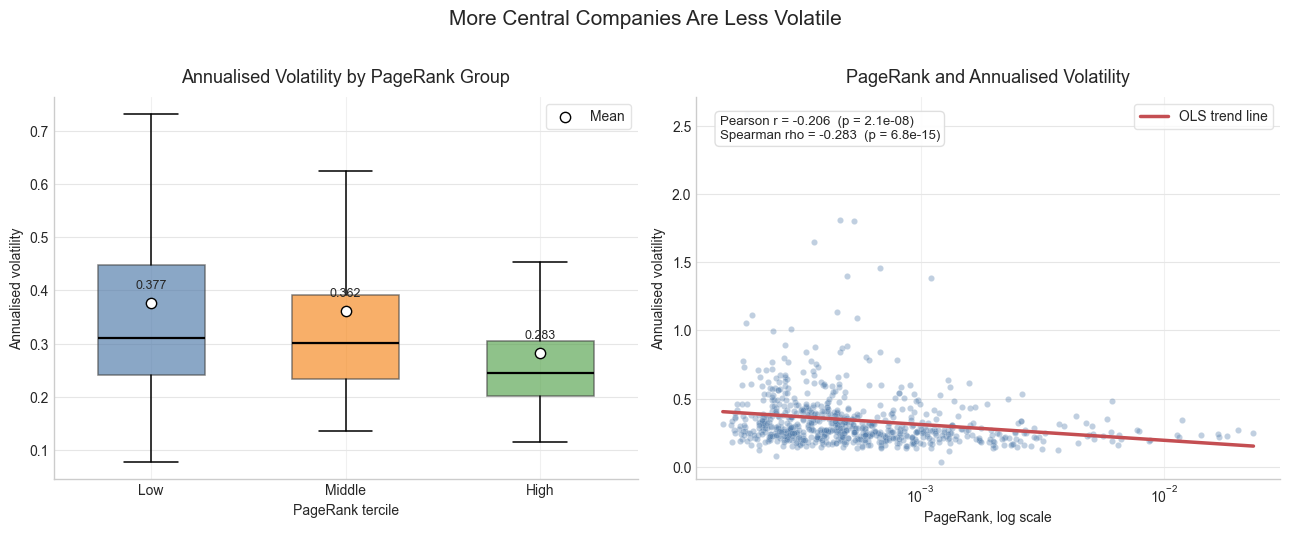

In [22]:
plt.style.use('seaborn-v0_8-whitegrid')

order = ['low centrality', 'middle centrality', 'high centrality']
colors = ['#4C78A8', '#F58518', '#54A24B']

fig, axes = plt.subplots(1, 2, figsize=(13, 5.2))

# --- Panel A: volatility by PageRank group ---
data = [
    df.loc[df['pagerank_group'] == label, 'vol_annualised'].dropna()
    for label in order
]

box = axes[0].boxplot(
    data,
    labels=['Low', 'Middle', 'High'],
    showfliers=False,
    patch_artist=True,
    widths=0.55,
    medianprops=dict(color='black', linewidth=1.6),
    boxprops=dict(linewidth=1.1),
    whiskerprops=dict(linewidth=1.1),
    capprops=dict(linewidth=1.1),
)

for patch, color in zip(box['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.65)
    patch.set_edgecolor('#444444')

group_means = [x.mean() for x in data]
axes[0].scatter(
    [1, 2, 3],
    group_means,
    color='white',
    edgecolor='black',
    s=55,
    zorder=3,
    label='Mean',
)

for i, mean_val in enumerate(group_means, start=1):
    axes[0].annotate(
        f'{mean_val:.3f}',
        xy=(i, mean_val),
        xytext=(0, 10),
        textcoords='offset points',
        ha='center',
        fontsize=9,
    )

axes[0].set_title('Annualised Volatility by PageRank Group', fontsize=13, pad=10)
axes[0].set_xlabel('PageRank tercile')
axes[0].set_ylabel('Annualised volatility')
axes[0].legend(frameon=True, facecolor='white', edgecolor='#DDDDDD', loc='upper right')


# --- Panel B: continuous PageRank relationship ---
axes[1].scatter(
    df['pagerank'],
    df['vol_annualised'],
    alpha=0.35,
    s=20,
    color='#4C78A8',
    edgecolor='white',
    linewidth=0.25,
)

# OLS visual trend line on log10(PageRank).
x_log = df['log_pagerank']
y = df['vol_annualised']
slope, intercept = np.polyfit(x_log, y, deg=1)

x_line = np.linspace(df['pagerank'].min(), df['pagerank'].max(), 300)
y_line = intercept + slope * np.log10(np.clip(x_line, 1e-12, None))

axes[1].plot(
    x_line,
    y_line,
    color='#C44E52',
    linewidth=2.5,
    label='OLS trend line',
)

annotation = (
    f'Pearson r = {pearson.statistic:.3f}  (p = {pearson.pvalue:.2g})\n'
    f'Spearman rho = {spearman.statistic:.3f}  (p = {spearman.pvalue:.2g})'
)
axes[1].text(
    0.04,
    0.95,
    annotation,
    transform=axes[1].transAxes,
    ha='left',
    va='top',
    fontsize=9.5,
    bbox=dict(boxstyle='round,pad=0.35', facecolor='white', edgecolor='#DDDDDD', alpha=0.93),
)

axes[1].set_xscale('log')
axes[1].set_title('PageRank and Annualised Volatility', fontsize=13, pad=10)
axes[1].set_xlabel('PageRank, log scale')
axes[1].set_ylabel('Annualised volatility')
axes[1].legend(frameon=True, facecolor='white', edgecolor='#DDDDDD', loc='upper right')


for ax in axes:
    ax.grid(axis='y', color='#E6E6E6')
    ax.grid(axis='x', color='#F0F0F0', which='major')
    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)
    ax.spines['left'].set_color('#CCCCCC')
    ax.spines['bottom'].set_color('#CCCCCC')

fig.suptitle(
    'More Central Companies Are Less Volatile',
    fontsize=15,
    y=1.02,
)

plt.tight_layout()
plt.savefig(HERE / 'centrality_groups_vs_volatility.png', dpi=180, bbox_inches='tight')
plt.show()

## 9. Save outputs

In [23]:
results = {
    'chosen_test': chosen,
    'chosen_stat': chosen_stat,
    'chosen_p': chosen_p,
    'levene_p': levene.pvalue,
    'classic_anova_F': classic_anova.statistic,
    'classic_anova_p': classic_anova.pvalue,
    'welch_anova_F': welch_F,
    'welch_anova_df1': welch_df1,
    'welch_anova_df2': welch_df2,
    'welch_anova_p': welch_p,
    'kruskal_p_sensitivity': kruskal.pvalue,
    'high_vs_low_test': pair_test_name,
    'high_vs_low_p': pair_test.pvalue,
    'pearson_log_pr_vol_r': pearson.statistic,
    'pearson_log_pr_vol_p': pearson.pvalue,
    'spearman_pr_vol_rho': spearman.statistic,
    'spearman_pr_vol_p': spearman.pvalue,
}

df.to_csv(HERE / 'centrality_volatility_company_table.csv', index=False)
group_summary.to_csv(HERE / 'centrality_volatility_group_summary.csv')
pd.Series(results).to_csv(HERE / 'centrality_volatility_test_results.csv')

## Interpretation

The centrality-volatility analysis shows a significant negative relationship between PageRank centrality and stock volatility.

The descriptive results show that annualised volatility decreases from the low-centrality group to the high-centrality group. Low-centrality companies have the highest average volatility, while high-centrality companies have the lowest average volatility.

The assumption checks reject normality in all three PageRank groups, and Levene's test rejects equal variances. Therefore, Welch ANOVA is the appropriate main omnibus test. The Welch ANOVA result is significant, meaning that annualised volatility differs across PageRank groups. The Kruskal-Wallis robustness check leads to the same conclusion.

The high-vs-low comparison confirms the direction of the effect: high-centrality companies are significantly less volatile than low-centrality companies. The continuous correlation checks also support this result. Both Pearson correlation on log(PageRank) and Spearman rank correlation show a significant negative association between PageRank and annualised volatility.

This rejects the naive hypothesis that more central companies are more volatile. Instead, PageRank centrality mainly captures large, visible, and stable firms that are frequently co-mentioned with other important companies.

The main conclusion is that centrality in the co-mention graph is not a risk amplifier. It is closer to a proxy for market importance and firm visibility, and it is negatively associated with stock volatility.